# 04 — Feature Engineering, périodes de soldes & export RAG

*Notebook*

> **Dépendances :** Nécessite la table RFM enrichie produite par **03_RFM_Enrichissement_Externe.ipynb**.


## 0. Reprise depuis les notebooks précédents

Nécessite les exports des notebooks **01**, **02** et **03**.

In [1]:
import os, pickle, gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")
sns.set_palette("husl")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/HM_dataset/"
except ImportError:
    print("Google Colab non détecté -> lecture des fichiers dans le dossier courant.")
    BASE_PATH = "./"

CUSTOMERS_PATH = os.path.join(BASE_PATH, "customers.csv")
ARTICLES_PATH = os.path.join(BASE_PATH, "articles.csv")
TRANSACTIONS_PATH = os.path.join(BASE_PATH, "transactions_train.csv")
INTERMEDIATE_DIR = os.path.join(BASE_PATH, "intermediate/")
os.makedirs(INTERMEDIATE_DIR, exist_ok=True)

try:
    with open(os.path.join(INTERMEDIATE_DIR, "nb01_customers.pkl"), "rb") as f:
        customers = pickle.load(f)
    articles = pd.read_csv(ARTICLES_PATH, dtype={"article_id": "int64"})

    with open(os.path.join(INTERMEDIATE_DIR, "nb02_transactions_accumulators.pkl"), "rb") as f:
        _acc = pickle.load(f)
    customer_stats = _acc["customer_stats"]
    customer_min_date = _acc["customer_min_date"]
    customer_max_date = _acc["customer_max_date"]
    customer_categories = _acc["customer_categories"]
    article_counts = _acc["article_counts"]
    channel_counts = _acc["channel_counts"]
    daily_revenue = _acc["daily_revenue"]
    daily_count = _acc["daily_count"]
    product_group_revenue = _acc["product_group_revenue"]
    total_rows = _acc["total_rows"]

    with open(os.path.join(INTERMEDIATE_DIR, "nb03_segment_summary.pkl"), "rb") as f:
        segment_summary = pickle.load(f)
except FileNotFoundError as e:
    raise FileNotFoundError(
        "Fichier(s) intermédiaire(s) introuvable(s). Exécute 01, 02 puis 03 avant ce notebook."
    ) from e

try:
    calendar_df = pd.read_pickle(os.path.join(INTERMEDIATE_DIR, "nb03_calendar_df.pkl"))
    print("calendar_df chargé (enrichissement météo/jours fériés disponible).")
except FileNotFoundError:
    print("calendar_df non trouvé -> la section 16 (soldes) utilisera les ventes brutes, sans enrichissement météo.")

print(f"Repris : {len(customer_stats):,} clients acheteurs, {total_rows:,} transactions, {articles.shape[0]:,} articles")


Mounted at /content/drive
calendar_df chargé (enrichissement météo/jours fériés disponible).
Repris : 1,362,281 clients acheteurs, 31,788,324 transactions, 105,542 articles


## 14. Feature Engineering — table de features clients (RFM enrichi)

On construit ici une table de features par client, réutilisable pour de la segmentation, un modèle
de churn, ou comme base structurée pour un chatbot RAG (section 15). Chaque feature est calculée à
partir de `customer_stats` déjà accumulé pendant le passage par blocs de la section 9, pas de
nouvelle lecture du fichier volumineux.

**Features engineerées et leur interprétation métier :**

| Feature | Définition | Interprétation métier |
|---|---|---|
| `total_spend` | Somme des prix payés | Valeur monétaire du client (le "M" de RFM) |
| `n_transactions` | Nombre total d'achats | Fréquence d'achat (le "F" de RFM) |
| `recency_days` | Jours écoulés depuis le dernier achat (vs fin du dataset) | Le "R" de RFM — un client récent est plus engagé |
| `tenure_days` | Durée entre 1er et dernier achat | Ancienneté réelle d'activité du client |
| `avg_basket_value` | `total_spend / n_transactions` | Panier moyen — pouvoir d'achat par visite |
| `purchase_frequency_per_month` | Achats normalisés par mois d'ancienneté | Régularité d'achat, comparable entre clients anciens et récents |
| `n_distinct_categories` | Nombre de `product_group_name` distincts achetés | Diversité/exploration du catalogue par le client |
| `segment_valeur` | Quartile de `total_spend` | Segment marketing actionnable (VIP, moyen, bas) |


**RFM** est une méthode classique en **marketing analytique / segmentation clients** qui consiste à décrire chaque client selon **3 dimensions comportementales** :

| Lettre                        | Signification                 | Question posée                                          | Exemple                                 |
| ----------------------------- | ----------------------------- | ------------------------------------------------------- | --------------------------------------- |
| **R — Recency (Récence)**     | Temps depuis le dernier achat | *Quand le client a-t-il acheté pour la dernière fois ?* | Achat il y a 5 jours → client récent    |
| **F — Frequency (Fréquence)** | Nombre d'achats réalisés      | *Combien de fois le client achète ?*                    | 25 commandes → client fréquent          |
| **M — Monetary (Montant)**    | Somme dépensée                | *Combien le client a dépensé ?*                         | 3000 € dépensés → client à forte valeur |


In [2]:
print(f"Clients avec au moins un achat : {len(customer_stats):,}")
print(f"Clients avec date de 1er/dernier achat trackée : {len(customer_min_date):,}")
print(f"Clients avec diversité de catégories trackée : {len(customer_categories):,}")


Clients avec au moins un achat : 1,362,281
Clients avec date de 1er/dernier achat trackée : 1,362,281
Clients avec diversité de catégories trackée : 1,362,281


Ces trois informations (`customer_min_date`, `customer_max_date`, `customer_categories`) ont été
calculées **directement dans la boucle principale de la section 9** (pas de nouvelle lecture du
fichier de 3,5 Go), ce qui rend cette section quasi instantanée.


In [3]:
# Rien à faire ici : customer_min_date, customer_max_date et customer_categories
# ont déjà été calculés pendant le passage par blocs de la section 9.
print("OK — utilisation directe des accumulateurs déjà calculés en section 9.")


OK — utilisation directe des accumulateurs déjà calculés en section 9.


In [4]:
customer_features = pd.DataFrame({
    "customer_id": list(customer_stats.keys()),
    "total_spend": [customer_stats[c][0] for c in customer_stats],
    "n_transactions": [customer_stats[c][1] for c in customer_stats],
})
customer_features["first_purchase"] = customer_features["customer_id"].map(customer_min_date)
customer_features["last_purchase"] = customer_features["customer_id"].map(customer_max_date)
customer_features["n_distinct_categories"] = customer_features["customer_id"].map(
    lambda c: len(customer_categories.get(c, []))
)

DATASET_END = pd.Timestamp("2020-09-22")
customer_features["recency_days"] = (DATASET_END - customer_features["last_purchase"]).dt.days
customer_features["tenure_days"] = (customer_features["last_purchase"] - customer_features["first_purchase"]).dt.days
customer_features["avg_basket_value"] = (customer_features["total_spend"] / customer_features["n_transactions"]).round(4)
customer_features["purchase_frequency_per_month"] = (
    customer_features["n_transactions"] / ((customer_features["tenure_days"] + 1) / 30)
).round(3)

customer_features["segment_valeur"] = pd.qcut(
    customer_features["total_spend"], q=4,
    labels=["Bas (Q1)", "Moyen-bas (Q2)", "Moyen-haut (Q3)", "Haut (Q4 - VIP)"]
)

# Fusion avec les attributs démographiques nettoyés
customers_features_full = customers.merge(customer_features, on="customer_id", how="left")

print(f"Dimensions : {customers_features_full.shape}")
customers_features_full.head()


Dimensions : (1371980, 16)


,customer_id,club_member_status,fashion_news_frequency,age,postal_code,age_group,total_spend,n_transactions,first_purchase,last_purchase,n_distinct_categories,recency_days,tenure_days,avg_basket_value,purchase_frequency_per_month,segment_valeur
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...,40-49,0.648983,21.0,2018-12-27,2020-09-05,4.0,17.0,618.0,0.0309,1.018,Moyen-haut (Q3)
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...,25-29,2.601932,86.0,2018-09-21,2020-07-08,7.0,76.0,656.0,0.0303,3.927,Haut (Q4 - VIP)
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...,20-24,0.704780,18.0,2018-09-20,2020-09-15,4.0,7.0,726.0,0.0392,0.743,Haut (Q4 - VIP)
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...,50-59,0.060983,2.0,2019-06-09,2019-06-09,1.0,471.0,0.0,0.0305,60.000,Bas (Q1)
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...,50-59,0.469695,13.0,2018-10-12,2020-08-12,5.0,41.0,670.0,0.0361,0.581,Moyen-haut (Q3)


### 14.1 Interprétation des distributions de features

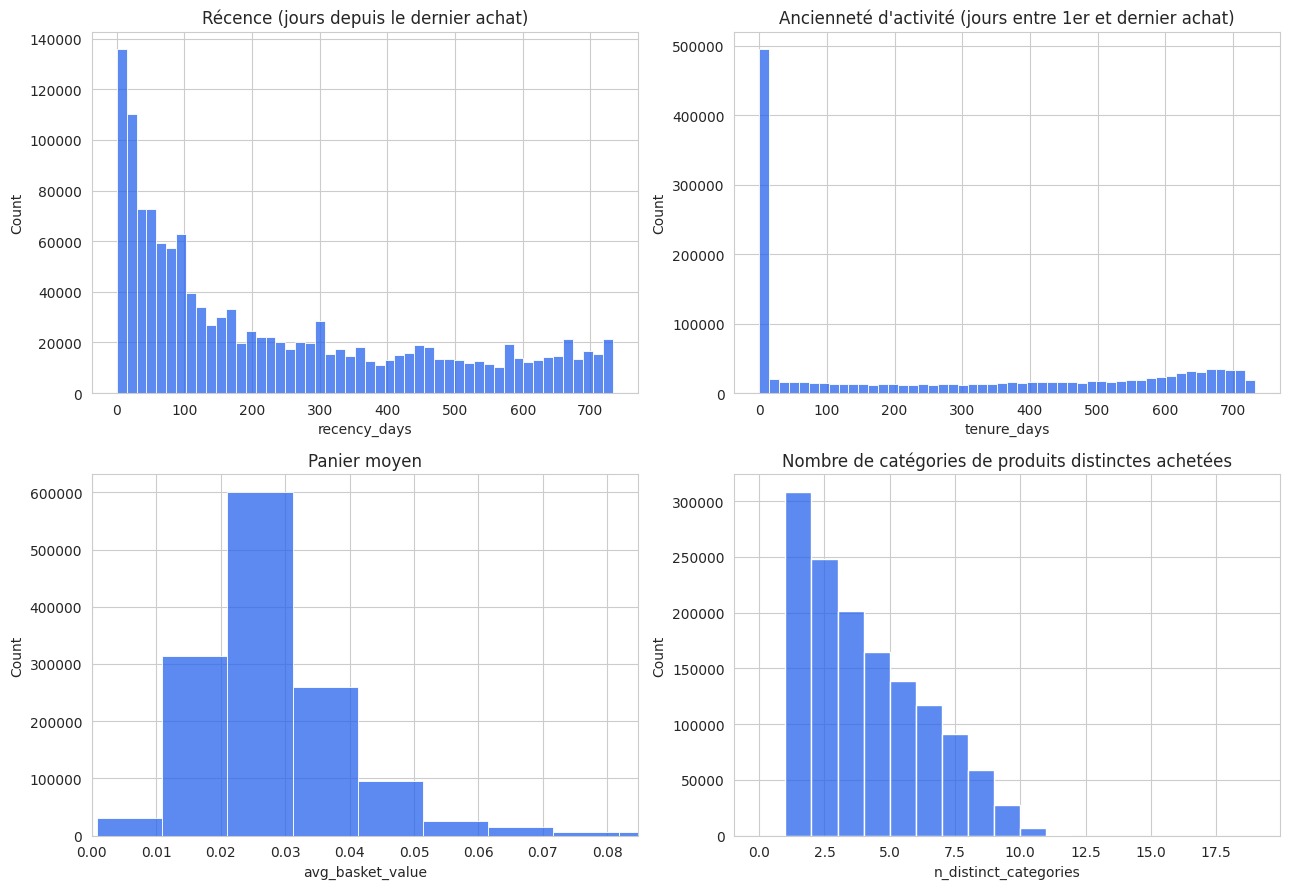

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(customer_features["recency_days"], bins=50, ax=axes[0,0], color="#2563eb")
axes[0,0].set_title("Récence (jours depuis le dernier achat)")

sns.histplot(customer_features["tenure_days"], bins=50, ax=axes[0,1], color="#2563eb")
axes[0,1].set_title("Ancienneté d'activité (jours entre 1er et dernier achat)")

sns.histplot(customer_features["avg_basket_value"], bins=50, ax=axes[1,0], color="#2563eb")
axes[1,0].set_xlim(0, customer_features["avg_basket_value"].quantile(0.99))
axes[1,0].set_title("Panier moyen")

sns.histplot(customer_features["n_distinct_categories"], bins=range(0,20), ax=axes[1,1], color="#2563eb")
axes[1,1].set_title("Nombre de catégories de produits distinctes achetées")

plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation :**
- **Récence** : une forte concentration proche de 0 indiquerait une base très active récemment ;
  une distribution étalée signale un mélange de clients actifs et dormants — utile comme signal de
  risque de churn.
- **Ancienneté** : une bimodalité (pic proche de 0 + pic proche de la durée totale du dataset)
  distinguerait les acheteurs ponctuels des clients fidèles de longue date.
- **Panier moyen** : distribution probablement asymétrique — quelques clients à panier élevé
  tirent la moyenne vers le haut, cohérent avec le constat Pareto de la section 11.
- **Diversité catégorielle** : un client achetant dans de nombreuses catégories est un client
  "généraliste" (cible pour du cross-sell), contrairement à un client mono-catégorie.


In [6]:
# Export de la table de features enrichie (nouveau jeu de données nettoyé + engineeré)
customers_features_full.to_csv(os.path.join(INTERMEDIATE_DIR, "customers_features.csv"), index=False)
print("Fichier exporté : customers_features.csv")
print(f"{customers_features_full.shape[0]:,} lignes x {customers_features_full.shape[1]} colonnes")


Fichier exporté : customers_features.csv
1,371,980 lignes x 16 colonnes


## 15. Export des jeux de données pour le chatbot RAG

On exporte ici, en plus de `customers_features.csv` (section 14), les autres jeux de données
dérivés des explorations précédentes — pensés pour être ingérés par un pipeline RAG (retrieval sur
données structurées, en complément d'un résumé narratif à embedder). Cette approche correspond au
même principe que le pipeline RAG utilisé côté ShopAnalytics : des tables agrégées pour les
requêtes factuelles precises, et un résumé texte pour les questions plus ouvertes.


In [7]:
# --- Performance par article (utile pour "quel est le produit le plus vendu ?", etc.) ---
agg_article = pd.DataFrame({
    "article_id": list(article_counts.keys()),
    "n_sales": list(article_counts.values()),
})
# revenu par article : recalcul léger à partir de product_group_revenue non disponible par article,
# on réutilise donc top10_df déjà construit en section 9.6 comme aperçu, et on exporte la table complète
products_performance = agg_article.merge(
    articles[["article_id", "prod_name", "product_group_name", "department_name", "index_name"]],
    on="article_id", how="left"
).sort_values("n_sales", ascending=False).reset_index(drop=True)

products_performance.to_csv(os.path.join(INTERMEDIATE_DIR, "products_performance.csv"), index=False)
print(f"products_performance.csv exporté : {products_performance.shape}")


products_performance.csv exporté : (104547, 6)


In [8]:
# --- Ventes quotidiennes (base pour daily_sales_calendar déjà enrichi en section 12.3) ---
daily_sales_export = pd.DataFrame({
    "date": list(daily_revenue.keys()),
    "chiffre_affaires": list(daily_revenue.values()),
    "nb_transactions": [daily_count[d] for d in daily_revenue.keys()],
}).sort_values("date").reset_index(drop=True)

daily_sales_export.to_csv(os.path.join(INTERMEDIATE_DIR, "daily_sales.csv"), index=False)
print(f"daily_sales.csv exporté : {daily_sales_export.shape}")

# Si la section 12 a été exécutée, on exporte aussi la version enrichie météo/jours fériés
try:
    calendar_df.to_csv(os.path.join(INTERMEDIATE_DIR, "daily_sales_calendar_enriched.csv"), index=False)
    print(f"daily_sales_calendar_enriched.csv exporté : {calendar_df.shape}")
except NameError:
    print("calendar_df non disponible — exécute la section 12 (météo/jours fériés) avant cette cellule pour l'inclure.")


daily_sales.csv exporté : (734, 3)
daily_sales_calendar_enriched.csv exporté : (734, 7)


In [9]:
# --- Résumé des segments clients (déjà calculé en section 11.2) ---
segment_summary.to_csv(os.path.join(INTERMEDIATE_DIR, "customer_segments_summary.csv"))
print("customer_segments_summary.csv exporté")

# --- Résumé par tranche d'âge ---
age_group_summary = customers_features_full[customers_features_full["n_transactions"] > 0].groupby(
    "age_group", observed=True
).agg(
    nb_clients=("customer_id", "count"),
    CA_total=("total_spend", "sum"),
    CA_moyen=("total_spend", "mean"),
    achats_moyen=("n_transactions", "mean"),
).round(2)
age_group_summary.to_csv(os.path.join(INTERMEDIATE_DIR, "age_group_summary.csv"))
print("age_group_summary.csv exporté")
age_group_summary


customer_segments_summary.csv exporté
age_group_summary.csv exporté


,nb_clients,CA_total,CA_moyen,achats_moyen
age_group,,,,
16-19,70512,16295.42,0.23,9.81
20-24,283315,152527.85,0.54,20.59
25-29,241373,201936.49,0.84,29.93
30-34,165397,126241.07,0.76,27.09
35-39,83028,57783.99,0.70,25.16
40-49,202797,135460.25,0.67,24.20
50-59,224865,151040.97,0.67,22.84
60-69,72049,36494.45,0.51,16.71
70+,18945,6865.49,0.36,11.62


### 15.1 Résumé narratif pour embedding RAG

En complément des tables structurées, un chatbot RAG bénéficie d'un **résumé texte** contenant les
insights déjà interprétés (pas seulement des chiffres bruts) plus facile à retrouver par similarité sémantique pour des questions ouvertes ("quels sont mes meilleurs clients ?", "quel est
l'impact de la météo sur les ventes ?").

On génère ce résumé dynamiquement à partir des variables
déjà calculées dans ce notebook, pour qu'il reste synchronisé avec les vraies données à chaque
exécution.


In [10]:
channel_labels = pd.Series(channel_counts).rename(index={1: "Magasin", 2: "En ligne"})

insights_md = f"""# H&M — Synthèse des insights (base de connaissances RAG)

## Vue d'ensemble
- {len(customers):,} clients, {len(articles):,} articles au catalogue, {total_rows:,} transactions
  ({min(daily_revenue.keys())} -> {max(daily_revenue.keys())}).
- {sum(1 for v in customer_stats.values() if v[1] > 0):,} clients ont effectué au moins un achat.

## Segmentation clients (RFM)
{segment_summary.to_markdown()}

## Chiffre d'affaires par tranche d'âge
{age_group_summary.to_markdown()}

## Chiffre d'affaires par catégorie de produit
{pd.Series(product_group_revenue).sort_values(ascending=False).round(1).to_markdown()}

## Canal de vente
{channel_labels.to_markdown()}
"""

with open(os.path.join(INTERMEDIATE_DIR, "insights_summary.md"), "w", encoding="utf-8") as f:
    f.write(insights_md)

print("insights_summary.md généré.")
print(insights_md[:500])


insights_summary.md généré.
# H&M — Synthèse des insights (base de connaissances RAG)

## Vue d'ensemble
- 1,371,980 clients, 105,542 articles au catalogue, 31,788,324 transactions
  (2018-09-20 -> 2020-09-22).
- 1,362,281 clients ont effectué au moins un achat.

## Segmentation clients (RFM)
| segment_valeur   |   nb_clients |   montant_moyen |   achats_moyen |   part_CA_totale_% |
|:-----------------|-------------:|----------------:|---------------:|-------------------:|
| Bas (Q1)         |       340644 |        0.04860


**Utilisation suggérée dans un pipeline RAG:**
1. `insights_summary.md` → découpé en chunks (par section `##`) et embeddé pour la recherche
   sémantique sur des questions ouvertes.
2. `customers_features.csv`, `products_performance.csv`, `daily_sales.csv`,
   `customer_segments_summary.csv`, `age_group_summary.csv` → chargés en base (SQL/vectorielle
   hybride) pour répondre précisément à des questions factuelles ("quel est le panier moyen des
   clients VIP ?"), via une route de requête structurée plutôt qu'une recherche purement
   sémantique — cohérent avec le routage sémantique déjà en place côté RAG ShopAnalytics
   (classification d'intention avant de choisir la branche structurée ou sémantique).


## 16. Périodes de soldes et impact sur le CA

Le dataset ne contient **aucune information directe sur les soldes** (pas de prix "avant/après
réduction", pas de flag promo). On utilise donc un **calendrier approximatif des soldes suédois/
H&M**, basé sur les périodes traditionnelles du marché nordique :

- **Soldes d'hiver** : ~27 décembre → 15 janvier
- **Soldes d'été** : ~25 juin → 15 juillet
- **Black Friday / Cyber Monday** : dernière semaine de novembre

> ⚠️ Ce sont des périodes **approximées**, pas des dates officielles confirmées par H&M ni
> présentes dans le dataset — à affiner si tu as accès au calendrier promotionnel réel.


In [11]:
sale_periods = [
    ("2018-11-20", "2018-12-02"),  # Black Friday / Cyber Monday 2018
    ("2018-12-27", "2019-01-15"),  # Soldes d'hiver 2018-2019
    ("2019-06-25", "2019-07-15"),  # Soldes d'été 2019
    ("2019-11-20", "2019-12-02"),  # Black Friday / Cyber Monday 2019
    ("2019-12-27", "2020-01-15"),  # Soldes d'hiver 2019-2020
    ("2020-06-25", "2020-07-15"),  # Soldes d'été 2020
]
sale_periods = [(pd.Timestamp(s).date(), pd.Timestamp(e).date()) for s, e in sale_periods]

daily_sales_sp = pd.DataFrame({
    "date": list(daily_revenue.keys()),
    "chiffre_affaires": list(daily_revenue.values()),
    "nb_transactions": [daily_count[d] for d in daily_revenue.keys()],
}).sort_values("date").reset_index(drop=True)

daily_sales_sp["is_sale_period"] = daily_sales_sp["date"].apply(
    lambda d: any(start <= d <= end for start, end in sale_periods)
)

print(f"Jours en période de soldes (approximée) : {daily_sales_sp['is_sale_period'].sum()} / {len(daily_sales_sp)}")
daily_sales_sp.groupby("is_sale_period")[["chiffre_affaires", "nb_transactions"]].agg(["mean", "median"]).round(1)


Jours en période de soldes (approximée) : 108 / 734


chiffre_affaires         nb_transactions         
                           mean  median            mean   median
is_sale_period                                                  
False                    1193.9  1131.3         42293.2  39059.0
True                     1270.7  1142.9         49192.6  44521.5

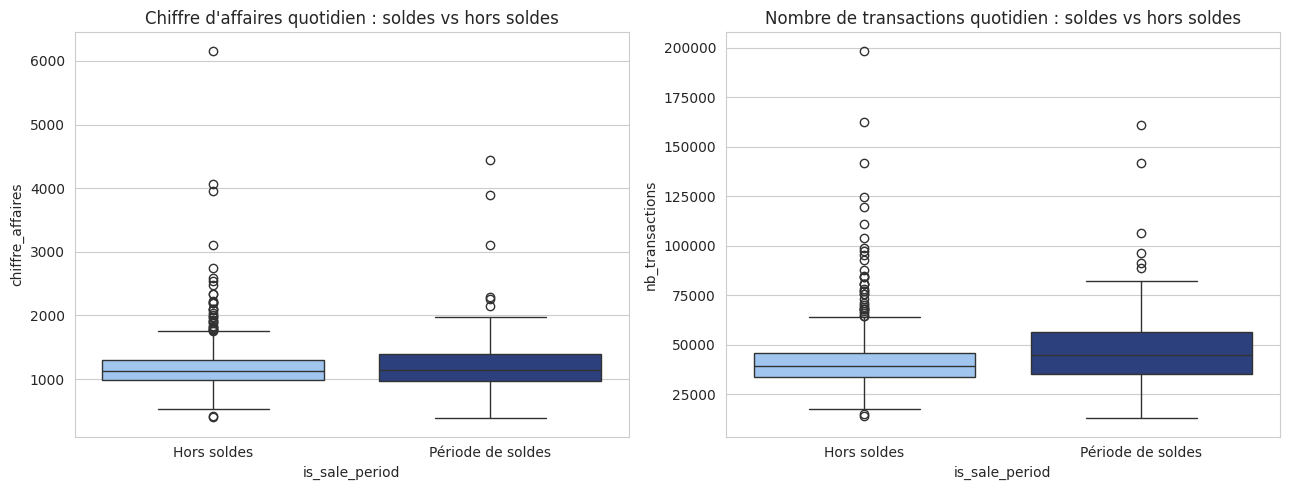

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=daily_sales_sp, x="is_sale_period", y="chiffre_affaires", ax=axes[0],
            palette=["#93c5fd", "#1e3a8a"])
axes[0].set_xticklabels(["Hors soldes", "Période de soldes"])
axes[0].set_title("Chiffre d'affaires quotidien : soldes vs hors soldes")

sns.boxplot(data=daily_sales_sp, x="is_sale_period", y="nb_transactions", ax=axes[1],
            palette=["#93c5fd", "#1e3a8a"])
axes[1].set_xticklabels(["Hors soldes", "Période de soldes"])
axes[1].set_title("Nombre de transactions quotidien : soldes vs hors soldes")

plt.tight_layout()
plt.show()
plt.close('all')


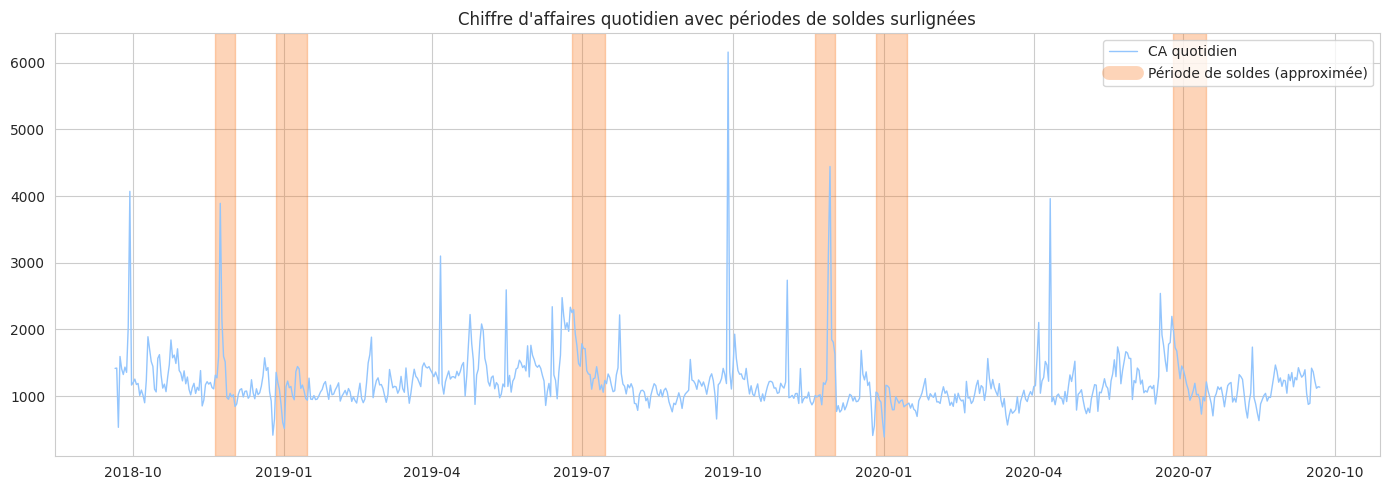

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_sales_sp["date"], daily_sales_sp["chiffre_affaires"], color="#93c5fd", linewidth=1, label="CA quotidien")

for start, end in sale_periods:
    ax.axvspan(start, end, color="#f97316", alpha=0.3)

ax.plot([], [], color="#f97316", alpha=0.3, linewidth=10, label="Période de soldes (approximée)")
ax.set_title("Chiffre d'affaires quotidien avec périodes de soldes surlignées")
ax.legend()
plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation :** si le CA et le volume de transactions sont significativement plus élevés
pendant les périodes de soldes identifiées, cela confirmerait que ces fenêtres approximées captent
bien un vrai effet promotionnel dans les données — un signal utile pour prévoir la demande ou
dimensionner les stocks en amont de ces périodes. Un écart faible ou nul suggérerait soit que les
dates réelles des soldes diffèrent de cette approximation, soit que la demande H&M est plus lissée
sur l'année que sur d'autres enseignes.

**Limite :** cette analyse ne capture pas les soldes flottants propres à certains pays/canaux, ni
les promotions ponctuelles hors des grandes périodes commerciales identifiées.


In [14]:
import gc

# Libère la mémoire des gros accumulateurs qui ne sont plus nécessaires à partir d'ici
# (déjà exploités pour produire customers_features_full, products_performance.csv, etc.)
_to_free = [
    "customer_categories", "customer_min_date", "customer_max_date",
    "weekly_counts", "count_by_age_category", "count_by_status",
    "price_sum_by_status", "customers_seen_by_status", "article_counts",
    "channel_counts", "price_sum_by_age", "count_by_age",
]
for name in _to_free:
    if name in globals():
        del globals()[name]

gc.collect()
print("Mémoire libérée avant la section 17 (modélisation ML).")


Mémoire libérée avant la section 17 (modélisation ML).
